In [5]:
!nvidia-smi

Sat Mar 21 14:08:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |     341MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode('sentences')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    # Cricket
    "Cricket was invented by England around the 19th century.",
    "India ranks highest in the viewership of cricket as it is their favourite sport.",
    "Cricket is played across 3 formats worldwide: Test, One Day, and T20.",
    "The bowler dismissed the batsman with a perfect yorker.",
    # Cooking
    "Cooking is one the essential part of human life.",
    "Cooking has now evolved from a basic essential to one of the biggest business markets.",
    "Lots of people are now making cooking their passion.",
    # Cyber Security
    "Cyber security is one of the most essential parts companies have started to build.",
    "Companies with people's data now spend a ton of money to secure their database from hackers.",
    "Ethical hackers are an important part of a cyber security team.",
]

embeddings = model.encode(sentences)
print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(10, 384)


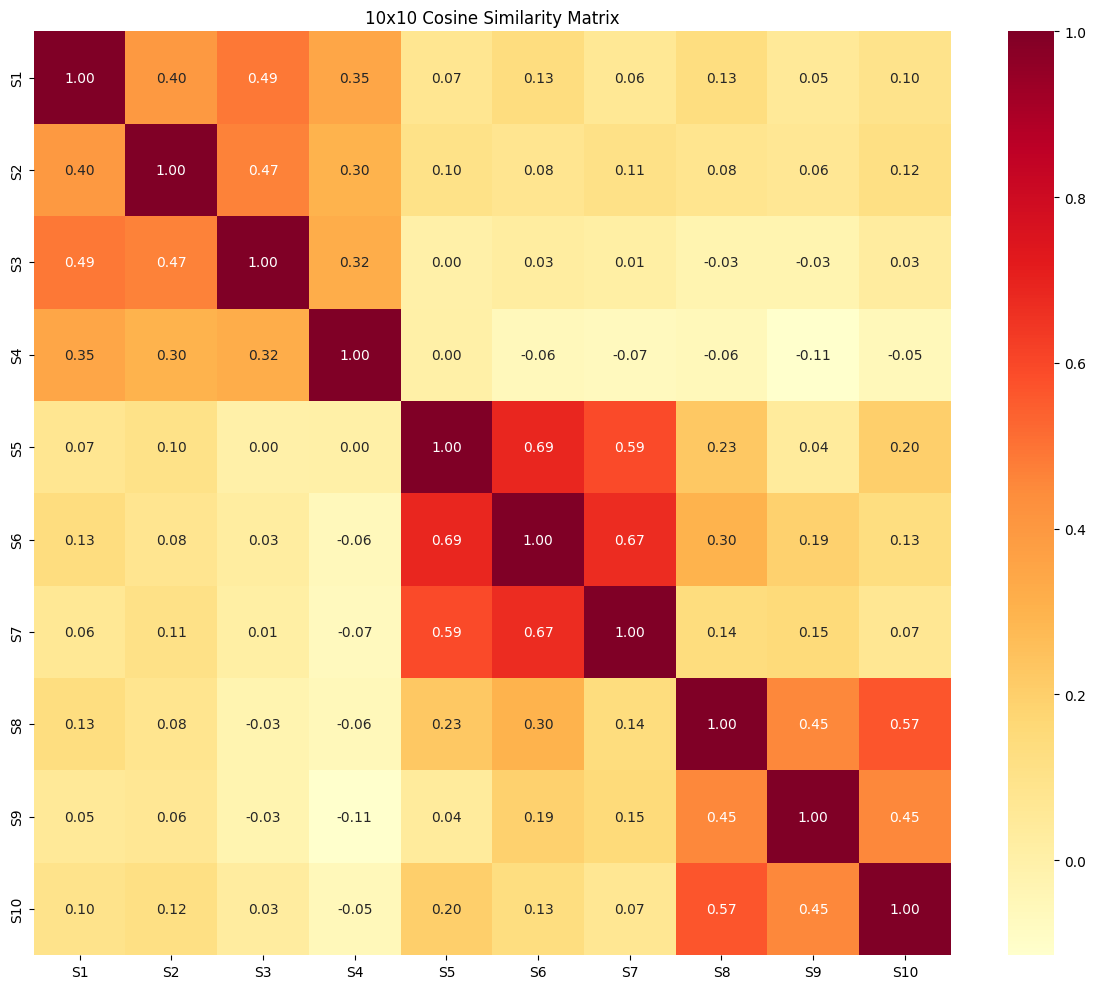

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute 10x10 cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=[f"S{i+1}" for i in range(10)],
    yticklabels=[f"S{i+1}" for i in range(10)],
    cmap="YlOrRd"
)
plt.title("10x10 Cosine Similarity Matrix")
plt.tight_layout()
plt.show()

In [9]:
# Query similarity search
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2
top2_indices = np.argsort(scores)[::-1][:2]

print("Query:", query)
print("\nTop 2 most similar sentences:")
for rank, idx in enumerate(top2_indices):
    print(f"{rank+1}. [{scores[idx]:.4f}] {sentences[idx]}")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:
1. [0.5821] The bowler dismissed the batsman with a perfect yorker.
2. [0.4471] Cricket is played across 3 formats worldwide: Test, One Day, and T20.
